In [16]:
import xarray as xr
import pandas as pd
import numpy as np
from weatherbench2 import regions
from weatherbenchX.metrics.deterministic import RMSE, MAE
from weatherbenchX.metrics import base as metrics_base
import apache_beam as beam
import numpy as np
import xarray as xr
import weatherbenchX
from weatherbenchX.data_loaders import xarray_loaders
from weatherbenchX.metrics import deterministic
from weatherbenchX.metrics import base as metrics_base
from weatherbenchX import aggregation
from weatherbenchX import weighting

from weatherbenchX import binning
from weatherbenchX import time_chunks
from weatherbenchX import beam_pipeline
import ipywidgets as widgets
from IPython.display import display, Markdown
from weatherbench2 import regions
import warnings
warnings.filterwarnings("ignore")

DOMAIN_DEFINITIONS = {
    "Global": {
        "latitude": slice(90, -90),
        "longitude": slice(0, 360),
    },
    "Northern Hemisphere": {
        "latitude": slice(90, 0),
        "longitude": slice(0, 360),
    },
    "Tropics": {
        "latitude": slice(23.5, -23.5),
        "longitude": slice(0, 360),
    },
    "Bangladesh": {
        "latitude": slice(26.7, 20.7),
        "longitude": slice(88.0, 92.7),
    },
    "Chile": {
        "latitude": slice(-17.5, -56.0),
        "longitude": slice(284.0, 294.0),
    },
    "Nigeria": {
        "latitude": slice(14.7, 4.0),
        "longitude": slice(2.7, 14.7),
    },
    "Ethiopia": {
        "latitude": slice(14.9, 3.4),
        "longitude": slice(33.0, 48.0),
    },
    "Kenya": {
        "latitude": slice(5.0, -4.7),
        "longitude": slice(33.9, 41.9),
    },
}

forecast_path = "gs://weatherbench2/datasets/graphcast/2020/date_range_2019-11-16_2021-02-01_12_hours-64x32_equiangular_conservative.zarr"
target_path   = "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr"
clim_path     = "gs://weatherbench2/datasets/era5-hourly-climatology/1990-2019_6h_64x32_equiangular_conservative.zarr"

variables = ["2m_temperature", "total_precipitation_6hr", "z_500"]

def preprocess_forecast(ds):
    if "geopotential" in ds.data_vars and "level" in ds["geopotential"].dims:
        ds["z_500"] = ds["geopotential"].sel(level=500).drop_vars("level")
    return ds
ds = xr.open_zarr(forecast_path, decode_timedelta=True)

start = pd.Timestamp("2020-01-01T00:00:00")
end   = pd.Timestamp("2020-12-31T00:00:00")

available_inits = pd.to_datetime(ds["time"].values)
mask_in_range = (available_inits >= start) & (available_inits < end)
mask_weekday = available_inits.weekday.isin([0, 3])
mask = mask_in_range & mask_weekday

selected_inits_pd = available_inits[mask]
init_times = selected_inits_pd.values.astype("datetime64[ns]")

desired_lead_hours = np.arange(0, 241, 24)
lead_times = desired_lead_hours.astype("timedelta64[h]").astype("timedelta64[ns]")

available_leads = ds["prediction_timedelta"].values
lead_times = np.array([lt for lt in lead_times if lt in available_leads], dtype="timedelta64[ns]")

print(f"Selected {len(init_times)} init times (Mondays & Thursdays between {start} and {end}):")
print(init_times[:6], "..." if len(init_times) > 6 else "")
print("Lead times (hours):", lead_times.astype("timedelta64[h]"))

forecast_loader = xarray_loaders.PredictionsFromXarray(
    path=forecast_path,
    variables=variables,
    rename_dimensions='ecmwf',
    preprocessing_fn=preprocess_forecast
)

target_loader = xarray_loaders.TargetsFromXarray(
    path=target_path,
    variables=variables,
    rename_dimensions='ecmwf',
    preprocessing_fn=preprocess_forecast
)

def load_clim():
    var_map = {
    # "2t": "2m_temperature",
    "z_500": "geopotential",
    # 'tp': 'total_precipitation_6hr',
    }

    clim = xr.open_zarr(clim_path, decode_timedelta=True)
    clim_var_map = {v: k for k, v in var_map.items()}

    clim = clim.rename_vars(clim_var_map)
    clim = clim[variables]
    clim["z_500"] = clim["z_500"].sel(level=500).drop_vars("level")
    return clim

times = time_chunks.TimeChunks(
    init_times=init_times,
    lead_times=lead_times,
    init_time_chunk_size=len(init_times),
    lead_time_chunk_size=len(lead_times)
)

Selected 208 init times (Mondays & Thursdays between 2020-01-01 00:00:00 and 2020-12-31 00:00:00):
['2020-01-02T00:00:00.000000000' '2020-01-02T12:00:00.000000000'
 '2020-01-06T00:00:00.000000000' '2020-01-06T12:00:00.000000000'
 '2020-01-09T00:00:00.000000000' '2020-01-09T12:00:00.000000000'] ...
Lead times (hours): [ 24  48  72  96 120 144 168 192 216 240]


In [17]:
clim = load_clim().compute()
metrics = {
  'rmse': deterministic.RMSE(),
  'ACC': deterministic.ACC(climatology=clim),
}
aggregator = aggregation.Aggregator(
  reduce_dims=['init_time', 'latitude', 'longitude'],
)

out_path = './out.nc'

root = beam.Pipeline(runner="DirectRunner")
beam_pipeline.define_pipeline(
    root=root,
    times=times,
    predictions_loader=forecast_loader,
    targets_loader=target_loader,
    metrics=metrics,
    aggregator=aggregator,
    out_path=out_path,
)
result = root.run()
result.wait_until_finish()

print("Pipeline finished. Check:", out_path)

Pipeline finished. Check: ./out.nc


In [3]:
xr.open_dataset('./out.nc').compute()

<xarray.Dataset> Size: 200B
Dimensions:                       (lead_time: 10)
Coordinates:
  * lead_time                     (lead_time) timedelta64[ns] 80B 1 days ... ...
Data variables:
    rmse.z_500                    (lead_time) float32 40B 41.56 81.9 ... 859.6
    rmse.2m_temperature           (lead_time) float32 40B 0.442 0.6129 ... 3.09
    rmse.total_precipitation_6hr  (lead_time) float32 40B 0.0003732 ... 0.001182

In [18]:
# --- Helpers used by the widget ------------------------------------------------
import numpy as np
import xarray as xr

# Map dropdown keys -> possible variable names in the Zarrs
VAR_MAP = {
    "2t":   ["2m_temperature", "2t", "t2m"],
    "tp6h": ["total_precipitation_6hr", "total_precipitation", "tp"],
    "z500": ["z_500", "z500", "geopotential"],
}

def _pick_var(ds, candidates):
    for v in candidates:
        if v in ds.data_vars:
            return v
    raise KeyError(f"None of {candidates} found in dataset. Have: {list(ds.data_vars)}")

def _maybe_add_z500(ds):
    # Create z_500 from 'geopotential' if present with a 'level' dim
    if "geopotential" in ds.data_vars and "level" in ds["geopotential"].dims:
        ds["z_500"] = ds["geopotential"].sel(level=500).drop_vars("level")
    return ds

def _slice_region(ds, region_name):
    r = DOMAIN_DEFINITIONS[region_name]
    lat_name = "latitude" if "latitude" in ds.coords else "lat"
    lon_name = "longitude" if "longitude" in ds.coords else "lon"

    lat = ds[lat_name]
    # Handle both ascending and descending latitude coordinates
    if lat[0] > lat[-1]:
        lat_slice = slice(r["latitude"].start, r["latitude"].stop)  # descending coord
    else:
        lat_slice = slice(r["latitude"].stop, r["latitude"].start) if r["latitude"].start > r["latitude"].stop else r["latitude"]

    return ds.sel({lat_name: lat_slice, lon_name: r["longitude"]})

def load_aligned(forecast_path, target_path, var_key, region_name):
    """
    Returns forecast and target DataArrays over the chosen region with matching
    (time, prediction_timedelta, lat, lon). Targets are looked up at valid time = init + lead.
    """
    f = xr.open_zarr(forecast_path, decode_timedelta=True)
    t = xr.open_zarr(target_path,   decode_timedelta=True)

    f = _maybe_add_z500(f)
    t = _maybe_add_z500(t)

    fv = _pick_var(f, VAR_MAP[var_key])
    tv = _pick_var(t, VAR_MAP[var_key])

    f = _slice_region(f[[fv]], region_name)
    t = _slice_region(t[[tv]], region_name)

    # Build valid-time matrix (init + lead) and select targets there
    # Xarray allows DataArray indexers with matching shape.
    valid_time = f["time"] + f["prediction_timedelta"]
    try:
        t_valid = t[tv].sel(time=valid_time)  # exact match
    except Exception:
        # If timestamps don’t line up exactly, fall back to nearest match within 3 hours
        t_valid = t[tv].sel(time=valid_time, method="nearest", tolerance=np.timedelta64(3, "h"))

    return f[fv], t_valid.rename(tv), "prediction_timedelta"

def metric_rmse(f_da, t_da):
    """
    RMSE collapsed over space and lead, returning one value per init time.
    """
    err2 = (f_da - t_da) ** 2
    # Average over everything except 'time'
    dims_to_mean = [d for d in err2.dims if d != "time"]
    return np.sqrt(err2.mean(dim=dims_to_mean, skipna=True))

def metric_acc(f_da, t_da, clim_ds=None, var_key=None, lead_name="prediction_timedelta"):
    """
    Simple pattern ACC (spatial correlation of anomalies) for each (time, lead),
    then averaged over lead to return a series over 'time'.
    """
    lat_name = "latitude" if "latitude" in f_da.dims else "lat"
    lon_name = "longitude" if "longitude" in f_da.dims else "lon"

    f_anom = f_da - f_da.mean(dim=(lat_name, lon_name))
    t_anom = t_da - t_da.mean(dim=(lat_name, lon_name))

    cov   = (f_anom * t_anom).mean(dim=(lat_name, lon_name))
    f_std = np.sqrt((f_anom**2).mean(dim=(lat_name, lon_name)))
    t_std = np.sqrt((t_anom**2).mean(dim=(lat_name, lon_name)))
    acc = cov / (f_std * t_std)

    if lead_name in acc.dims:
        acc = acc.mean(dim=lead_name, skipna=True)
    return acc
# -------------------------------------------------------------------------------


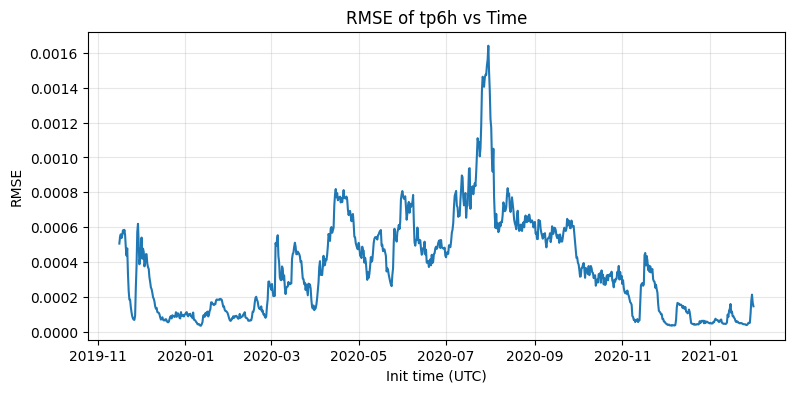

In [21]:
# ───────── Widgets + time-series plot (uses objects/functions defined in earlier cells) ─────────
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import xarray as xr

# Variable keys expected by your helpers (the same ones you used elsewhere)
VAR_KEYS = [("2t", "2t"), ("tp6h", "tp6h"), ("z500", "z500")]

# ── UI
w_region = widgets.Dropdown(options=list(DOMAIN_DEFINITIONS.keys()),
                            value="Ethiopia", description="Region:")
w_metric = widgets.Dropdown(options=["RMSE", "ACC"],
                            value="RMSE", description="Metric:")
w_var    = widgets.Dropdown(options=VAR_KEYS, value="2t", description="Variable:")
w_run    = widgets.Button(description="Run Verification", button_style="success")
w_log    = widgets.Output()

ui_box = widgets.VBox([w_region, w_metric, w_var, w_run, w_log])
display(ui_box)

def on_run(_):
    with w_log:
        w_log.clear_output()
        print(f"Selected region: {w_region.value}")
        print(f"Selected metric: {w_metric.value}")
        print(f"Selected variable: {w_var.value}")
        print("Loading data...")

    try:
        # Use your previously defined helper to get forecast/target aligned on the same grid/times
        f, t, lead_name = load_aligned(forecast_path, target_path, w_var.value, w_region.value)

        with w_log:
            print("Computing metrics...")

        # Use your metric helpers (already defined in earlier cells)
        if w_metric.value == "RMSE":
            series = metric_rmse(f, t)            # returns DataArray with dim 'time' (init times)
            ylabel = "RMSE"
            title_metric = "RMSE"
        else:
            # load the climatology you configured earlier for ACC
            try:
                clim = xr.open_zarr(clim_path, decode_timedelta=True)
            except Exception:
                clim = xr.open_zarr(target_path)  # fallback if clim path not reachable
            series = metric_acc(f, t, clim_ds=clim, var_key=w_var.value, lead_name=lead_name)
            ylabel = "ACC"
            title_metric = "ACC"

        # Plot (like your screenshot)
        times = pd.to_datetime(series["time"].values)
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(times, series.values)
        ax.set_title(f"{title_metric} of {w_var.value} vs Time")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Init time (UTC)")
        ax.grid(True, alpha=0.3)

        with w_log:
            print("Done ✅")
        display(fig)
        plt.close(fig)

    except Exception as e:
        with w_log:
            print("❌ Error:", repr(e))

w_run.on_click(on_run)
